# Thesis Demo: Adaptive FEM for Bayesian Inverse Problems
Standard numerical methods fail when material coefficients are discontinuous (e.g., an inclusion in a composite material). This project implements an **Adaptive Finite Element Method (AFEM)** that recovers optimal convergence rates by automatically refining the mesh only where necessary.

**Key Application:** In Bayesian Inverse problems, we run the forward solver thousands of times. AFEM minimizes the computational cost per solve, making the inverse inference tractable.

## 1) Forward Problem 
We solve on $D=(0,1)$ with homogeneous Dirichlet boundary conditions:
$$-\frac{d}{dx}\left(a(x;(x_0, r))\,u'(x)\right) = f(x), \quad u(0)=u(1)=0.$$

* $ u $ is the physical field (think temperature/pressure/potential) 
* $ a(x) $ is a material coefficient (think conductivity, permeability, or heat transfer rate). 
* $ a(x) $ is known to be discountinous, jumping from $a_{out}=1$ to $a_{in}=5$ inside an inclusion. 
* The inclusion in domain is defined to be a ball centered at $x_0=0.5$ with radius $r$:
$$a(x;r)=\begin{cases} a_{\text{in}}, & |x-x_0|\le r\\ a_{\text{out}}, & \text{else.}\end{cases}$$

* **Math Consequence:** The solution $u$ is continuous, but its gradient $\nabla u$ is discontinuous.
* **Numerical Consequence:** Standard FEM error concentrates at the interface. Uniform refinement wastes resources solving smooth regions; we need **Adaptive Refinement**.

In [35]:
from numpy.polynomial.legendre import leggauss
from scipy.stats import linregress
import numpy as np
import matplotlib
import matplotlib.pyplot as plt 

# ==========================================
# 1. PROBLEM SETUP (The Inclusion)
# ==========================================

def a0(x, beta):
    """
    Discontinuous coefficient a(x).
    beta = (x_star, r) -> Center and radius of inclusion.
    Returns 2.0 inside inclusion, 1.0 outside.
    """
    x_star, r_val = beta
    x = np.asarray(x)
    # Using 5.0 for a strong contrast (stiffer material)
    condition = (x >= (x_star - r_val)) & (x <= (x_star + r_val))
    return np.where(condition, 5, 1.0)

def f(x, beta):
    """Source term f(x) = 1.0"""
    x = np.asarray(x)
    return np.ones_like(x)



## 2. Finite Element Methods 

* Finite element methods aims to dicretize a space, and approximate a particular function using linear combinations of basis function $\phi_i$. 

* These are examples of uniform mesh refinements. The domain of interest is bisected in "uniform" equal sizes. 

![1 d FEM .png](<attachment:1 d FEM .png>) 
![2d fem.png](<attachment:2d fem.png>)

* This is an example of uniform meshs dicretization when there is an inclusion. 

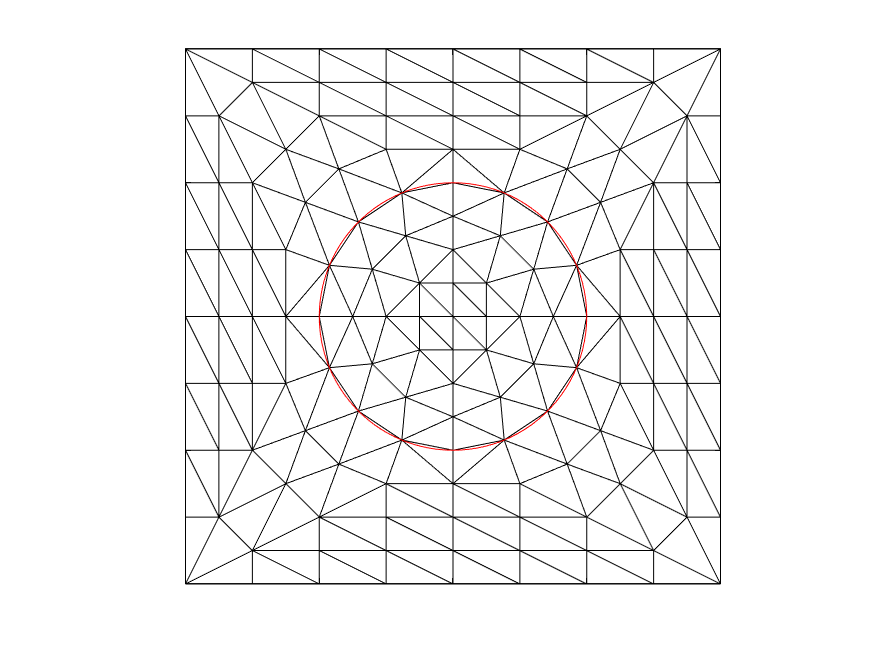

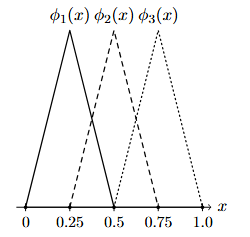
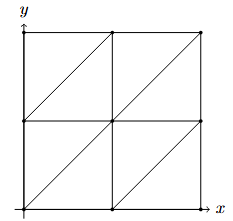

In [36]:
# ==========================================
# 2. QUADRATURE & FEM UTILS
# ==========================================

def get_discont_points(x_left, x_right, beta):
    """Finds discontinuity points within an element [x_left, x_right]."""
    x_star, r_val = beta
    pts = []
    p1 = x_star - r_val
    p2 = x_star + r_val
    
    if x_left < p1 < x_right:
        pts.append(p1)
    if x_left < p2 < x_right:
        pts.append(p2)
    return pts

def GL(x_left, x_right, func):
    """Standard Gauss-Legendre Quadrature (5 points)."""
    # 5-point quadrature is sufficient for this degree
    xi, ci = leggauss(5)
    # Map from [-1, 1] to [x_left, x_right]
    x_mapped = 0.5 * ((x_right - x_left) * xi + (x_right + x_left))
    integrand_values = func(x_mapped)
    return 0.5 * (x_right - x_left) * np.dot(ci, integrand_values)

def piecewise_GL(integrand, x_left, x_right, discont_points=None):
    """
    Key Helper: Splits integration if a discontinuity exists in the element.
    This prevents O(h^1/2) error pollution.
    """
    if discont_points is None or len(discont_points) == 0:
        return GL(x_left, x_right, integrand)
    
    # Filter points actually inside interval
    splits = sorted([p for p in discont_points if x_left < p < x_right])
    pts = [x_left] + splits + [x_right]
    
    total = 0.0
    for i in range(len(pts) - 1):
        total += GL(pts[i], pts[i+1], integrand)
    return total

def phi_i(i, x, mesh):
    """1D Hat Basis Function for node i."""
    x = np.asarray(x)
    N = len(mesh) - 1
    
    # Left boundary
    if i == 0:
        cond = (x >= mesh[0]) & (x <= mesh[1])
        return np.where(cond, (mesh[1] - x) / (mesh[1] - mesh[0]), 0.0)
    # Right boundary
    elif i == N:
        cond = (x >= mesh[N-1]) & (x <= mesh[N])
        return np.where(cond, (x - mesh[N-1]) / (mesh[N] - mesh[N-1]), 0.0)
    # Interior nodes
    else:
        left_cond = (x >= mesh[i-1]) & (x <= mesh[i])
        right_cond = (x > mesh[i]) & (x <= mesh[i+1])
        left_val = (x - mesh[i-1]) / (mesh[i] - mesh[i-1])
        right_val = (mesh[i+1] - x) / (mesh[i+1] - mesh[i])
        return np.where(left_cond, left_val, np.where(right_cond, right_val, 0.0))

def dphi_i_slope(i, k, mesh):
    """Returns slope of phi_i on element k (constant)."""
    dx = mesh[k+1] - mesh[k]
    if i == k: return -1.0/dx      # Left node of element -> slope down
    elif i == k+1: return 1.0/dx   # Right node of element -> slope up
    return 0.0

#########################
### ASSEMBLY & SOLVER ###
#########################

def assemble_system(mesh, beta):
    N = len(mesh)
    S = np.zeros((N, N))
    F = np.zeros(N)
    
    # --- Matrix Assembly ---

    for k in range(N - 1): # Loop over elements
        x_L, x_R = mesh[k], mesh[k+1]
        disconts = get_discont_points(x_L, x_R, beta)
        
        # Local Stiffness terms (gradients)
        # On element k, only phi_k and phi_{k+1} are non-zero
        for i_local in [k, k+1]:
            for j_local in [k, k+1]:
                def integrand_S(x):
                    # a(x) * grad(phi_i) * grad(phi_j)
                    s_i = dphi_i_slope(i_local, k, mesh)
                    s_j = dphi_i_slope(j_local, k, mesh)
                    return a0(x, beta) * s_i * s_j
                
                val = piecewise_GL(integrand_S, x_L, x_R, disconts)
                S[i_local, j_local] += val

        # --- Force Vector Assembly ---
        for i_local in [k, k+1]:
            def integrand_F(x):
                return f(x, beta) * phi_i(i_local, x, mesh)
            F[i_local] += piecewise_GL(integrand_F, x_L, x_R, disconts)
            
    # Apply Dirichlet BCs: u(0)=0, u(1)=0
    S_inner = S[1:-1, 1:-1]
    F_inner = F[1:-1]
    
    return S_inner, F_inner

def solve_fem(mesh, beta):
    S_in, F_in = assemble_system(mesh, beta)
    c_inner = np.linalg.solve(S_in, F_in)
    # Pad with zeros for boundary conditions
    return np.concatenate(([0.0], c_inner, [0.0]))

##############################################
### Error Computation, Marking, Refinement ###
##############################################
def r(x, mesh, uh, beta):
    # 'uh' and 'mesh' are not strictly needed since a'(x)=0 almost everywhere.
    # The interior PDE says r(x) = f(x) + slope*a'(x), and here r(x) is taken as f(x).
    return f(x, beta)

def element_residual_l2(mesh, e, beta):
    """
    Compute the L2 norm squared of the cell residual on element T = [mesh[e], mesh[e+1]].
    If r(x) is piecewise constant on T, then the L2 norm squared is (r_T)^2 * h.
    When T is cut by a discontinuity, we integrate piecewise.
    """
    a, b = mesh[e], mesh[e+1]
    h = b - a
    
    discont_points = get_discont_points(a, b, beta)
    
    # Define the integrand that includes the dependence on beta.
    def interior_integrand(x_val):
        # Use r(x, ..., beta) so that the effect of beta is incorporated.
        return r(x_val, None, None, beta)**2

    # Integrate using piecewise_GL, splitting at the discontinuities if needed.
    r_sq = piecewise_GL(interior_integrand, x_left=a, x_right=b, discont_points=discont_points)
    return r_sq


def slope_at_node(mesh, uh, i, side):
    """
    Return the slope of the piecewise-linear FE solution uh on the element
    adjacent to node i from the given side ('left' or 'right').
    """
    n = len(mesh) - 1
    if side == 'left':
        if i == 0:
            return 0.0
        else:
            dx = mesh[i] - mesh[i-1]
            return (uh[i] - uh[i-1]) / dx
    elif side == 'right':
        if i >= n:
            return 0.0
        else:
            dx = mesh[i+1] - mesh[i]
            return (uh[i+1] - uh[i]) / dx
    else:
        raise ValueError("side must be 'left' or 'right'.")

def flux_jump(mesh, uh, i, a0_func):
    """
    Compute the jump in the numerical flux at the node mesh[i] (assumed interior).
    The flux is sigma = a0 * (approximate derivative). We define:
      sigma_left  = a0(x_i^-) * slope on [mesh[i-1], mesh[i]],
      sigma_right = a0(x_i^+) * slope on [mesh[i], mesh[i+1]].
    The jump is then: j(x_i) = sigma_right - sigma_left.
    
    Parameters:
      mesh    : array of node coordinates.
      uh      : array of nodal values of the FE solution.
      i       : the index of an interior node.
      a0_func : a function to evaluate a0 at a given x.
    
    Returns:
      float: the flux jump at node i.
    """
    slope_left = slope_at_node(mesh, uh, i, 'left')
    slope_right = slope_at_node(mesh, uh, i, 'right')
    # Use a small perturbation to evaluate a0 on either side.
    a_left  = a0_func(mesh[i] - 1e-9)
    a_right = a0_func(mesh[i] + 1e-9)
    sigma_left  = a_left * slope_left
    sigma_right = a_right * slope_right
    return sigma_right - sigma_left

def sum_of_error(i, mesh, nodal, beta):
    """
    Compute the error indicator for element i.
    It consists of two parts:
      - A residual term: h^2 * (L2 norm squared of the residual on element i).
      - A boundary term: h * (flux jump at the element boundary)^2.
    """
    x_left = mesh[i]
    x_right = mesh[i+1]
    h = x_right - x_left
    # Residual error on the element (incorporating beta)
    residual_sq = element_residual_l2(mesh, i, beta)
    # Flux jump error. Note: pass a lambda that fixes beta in the coefficient function.
    boundary_sq = flux_jump(mesh, nodal, i, lambda x: a0(x, beta)) ** 2
    return h**2 * residual_sq + h * boundary_sq


def sum_of_error_list(mesh, nodal, beta):
    """
    Return the error indicator for each element, given the mesh, nodal values, and beta.
    """
    return [sum_of_error(i, mesh, nodal, beta) for i in range(len(mesh) - 1)]


def refine_mesh(mesh, element_index):
    """
    Refine the element [mesh[element_index], mesh[element_index+1]] by bisection.
    """
    x_left = mesh[element_index]
    x_right = mesh[element_index+1]
    midpoint = 0.5 * (x_left + x_right)
    # Insert the midpoint after mesh[element_index]
    return mesh[:element_index+1] + [midpoint] + mesh[element_index+1:]


def element_selection(errors, epsilon):
    """
    Given an array-like 'errors' (one error per element) and a tolerance epsilon,
    return a list of element indices to refine (sorted in descending order).
    """
    errors = np.asarray(errors)
    print(errors.shape)
    # Find all indices where error exceeds epsilon.
    indices = np.nonzero(errors > epsilon)[0]
    # Sort in descending order so that when refining, index shifts are avoided.
    indices = np.sort(indices)[::-1]
    return indices.tolist()

def dorfler_marking(errors, theta):
    errors = np.asarray(errors).flatten()
    print(errors.shape)
    total_error = np.sum(errors)
    sorted_indices = np.argsort(-errors)  # descending order
    cum_sum = np.cumsum(errors[sorted_indices])
    num_marked = np.searchsorted(cum_sum, theta * total_error) + 1
    marked_indices = sorted_indices[:num_marked]
    return marked_indices.tolist()

def element_refinement(mesh, element_indices):
    mesh_arr = np.array(mesh)
    element_indices = np.array(element_indices, dtype=int)
    # Compute midpoints for each marked element.
    midpoints = 0.5 * (mesh_arr[element_indices] + mesh_arr[element_indices + 1]).flatten()
    # Concatenate the original mesh with the new midpoints, then sort.
    new_mesh = np.sort(np.concatenate((mesh_arr, midpoints)))
    return new_mesh.tolist()

def qoi_J(mesh, u_full, beta):
    """
    J(u_h) = ∫_0^1 f(x,beta) u_h(x) dx
    In FEM: J ≈ u^T F. Since u(0)=u(1)=0, we can use inner parts:
      J = u_inner^T F_inner
    where F_inner is from assemble_system(mesh,beta).
    """
    _, F_inner = assemble_system(mesh, beta)      # size: (N-2,)
    u_inner = u_full[1:-1]                        # size: (N-2,)
    return float(np.dot(u_inner, F_inner))

##############
### Extras ###
##############


def fit_slope(ddof, err):
    """
    Fit slope on last tail_k points in log-log scale.
    Uses abs(err) to avoid log issues.
    """
    ddof = np.asarray(ddof)
    err = np.asarray(err)

    if len(ddof) < 2:
        return np.nan, np.nan

    x_fit = np.log(ddof)
    y_fit = np.log(err)
    slope, intercept = np.polyfit(x_fit, y_fit, 1)
    return slope, intercept

def plot_qoi_convergence(beta, theta=0.5, max_iter=25,
                         l_min=3, l_max=14):
    """
    1) Build a fine AFEM benchmark u_ref (truth)
    2) Run AFEM history + Uniform history
    3) Plot |J_ref - J_h| vs DoF (log-log) and fit slopes
    """

    # --- AFEM history (coarse->refined) ---
    afem_meshes, afem_sols, afem_ddof, afem_J = afem_history(beta, theta=theta, max_iter=max_iter)
    J_ref = afem_J[-1]
    mesh_ref = afem_meshes[-1]
    u_ref = afem_sols[-1]
    afem_err = J_ref - afem_J

    # --- uniform history ---
    uni_ddof, uni_J, uni_meshes, uni_sols = uniform_history(beta, l_min=l_min, l_max=l_max)
    uni_err = J_ref - uni_J

    # --- fit slopes on tail (optional but nice for interview) ---
    afem_slope, afem_b = fit_slope(afem_ddof[:max_iter-1], afem_err[:max_iter-1])
    uni_slope,  uni_b  = fit_slope(uni_ddof,  uni_err)

    # build fitted lines for plotting
    def fit_line(ddof, slope, intercept):
        return np.exp(intercept) * np.power(ddof, slope)

    afem_fit = fit_line(afem_ddof, afem_slope, afem_b) if np.isfinite(afem_slope) else None
    uni_fit  = fit_line(uni_ddof,  uni_slope,  uni_b)  if np.isfinite(uni_slope)  else None

    # --- plot ---
    plt.figure(figsize=(10, 6))
    plt.loglog(afem_ddof[:max_iter-1], np.abs(afem_err[:max_iter-1]), 'o-', label=f'AFEM |J_ref - J_h| (slope={afem_slope:.2f})')
    plt.loglog(uni_ddof,  np.abs(uni_err),  'o-', label=f'Uniform |J_ref - J_h| (slope={uni_slope:.2f})')

    if afem_fit is not None:
        plt.loglog(afem_ddof, np.abs(afem_fit), '--', alpha=0.8)
    if uni_fit is not None:
        plt.loglog(uni_ddof,  np.abs(uni_fit),  '--', alpha=0.8)

    plt.xlabel('Degrees of Freedom (DoF = # interior nodes)')
    plt.ylabel('QoI Error  |J_ref - J_h|  (log-log)')
    plt.title('AFEM vs Uniform Convergence (QoI surrogate for energy)')
    plt.grid(True, which='both', linestyle='--', linewidth=0.5)
    plt.legend()
    plt.show()

    # print quick debug table
    print("J_ref =", J_ref)
    print("AFEM ddof:", afem_ddof)
    print("AFEM err :", afem_err)
    print("UNI  ddof:", uni_ddof)
    print("UNI  err :", uni_err)

    plt.figure() 
    plt.plot(mesh_ref, u_ref, "ro-", label = "Exact Ref", linewidth = 1, alpha = 1, markersize = 2)
    plt.plot(afem_meshes[-1], afem_sols[-1], "bo-", label="AFEM Solver", linewidth = 0.5, alpha = 0.5, markersize = 1)
    plt.plot(uni_meshes[-1], uni_sols[-1], "bo-", label = "Uniform Solver", linewidth = 0.5, alpha=0.5, markersize = 1)
    plt.show()




## 3. AFEM Solver Loop 
Instead of refining everywhere, we loop through 4 steps:
1. Solve on current mesh 
2. Estimate local error indicators $\eta_i$ on each element $i$
3. Mark a minimal set of elements $M_i$ such that: 
   
   $$ \sum_{T\in M_i}\eta_T^2 \geq \vartheta \sum_{T \in \mathcal{T}}\eta_T^2 .$$

   
   This means that the selected elements represents more that $\theta$ than the total error.
4. Refine Marked elements via Bisection of elements 
5. Repeat the loop

In [ ]:

####################################
### Solver Loops - AFEM, Uniform ###
####################################


def afem_history(beta, theta=0.5, max_iter=30):
    """
    Collect (meshes, sols, ddof_list, J_list) for AFEM iterations.
    """
    meshes, sols, ddofs, J_list = [], [], [], []
    mesh = np.linspace(0, 1, 5)

    for it in range(max_iter):
        u = solve_fem(mesh, beta)

        meshes.append(mesh.copy())
        sols.append(u.copy())
        ddofs.append(len(mesh) - 2)

        J_list.append(qoi_J(mesh, u, beta))

        # mark & refine
        errors = sum_of_error_list(mesh, u, beta)
        marked = dorfler_marking(errors, theta)
        if len(marked) == 0:
            break
        mesh_new = element_refinement(mesh, marked)
        if len(mesh_new) == len(mesh):
            break
        mesh = mesh_new

    return meshes, sols, np.array(ddofs, dtype=float), np.array(J_list, dtype=float)

## comment: Uniform refinement bisects every element, even where the solution is smooth → wasted DoF for interface problems.



def uniform_history(beta, l_min=3, l_max=14):
    """
    Collect (ddof_list, J_list) for uniform refinement meshes:
      N_nodes = 2^l + 1
      ddof = N_nodes - 2
    """
    ddofs, J_list, uni_meshes, uni_sols = [], [], [], []
    for l in range(l_min, l_max + 1):
        mesh = np.linspace(0.0, 1.0, 2**l + 1)
        u = solve_fem(mesh, beta)
        ddofs.append(len(mesh) - 2)
        J_list.append(qoi_J(mesh, u, beta))
        uni_meshes.append(mesh)
        uni_sols.append(u)
    return np.array(ddofs, dtype=float), np.array(J_list, dtype=float), uni_meshes, uni_sols




## 4. Results & Convergence
Notice how the mesh points cluster strictly around the inclusion interface (the "danger zone") while the rest of the domain remains coarse.

**Convergence (Squared Error):**
* **Uniform Mesh:** Slope $\approx -1$. The singularity limits performance.
* **AFEM:** Slope $\approx -2$. We recover the optimal rate for linear elements ($O(N^{-2})$ in energy squared).

(4,)
(6,)
(8,)
(10,)
(14,)
(18,)
(22,)
(23,)
(24,)
(26,)
(34,)
(41,)
(59,)
(71,)
(91,)
(121,)
(144,)
(216,)
(259,)
(269,)
(346,)
(432,)
(513,)
(693,)
(900,)
(1054,)
(1616,)
(1959,)
(2667,)
(3360,)


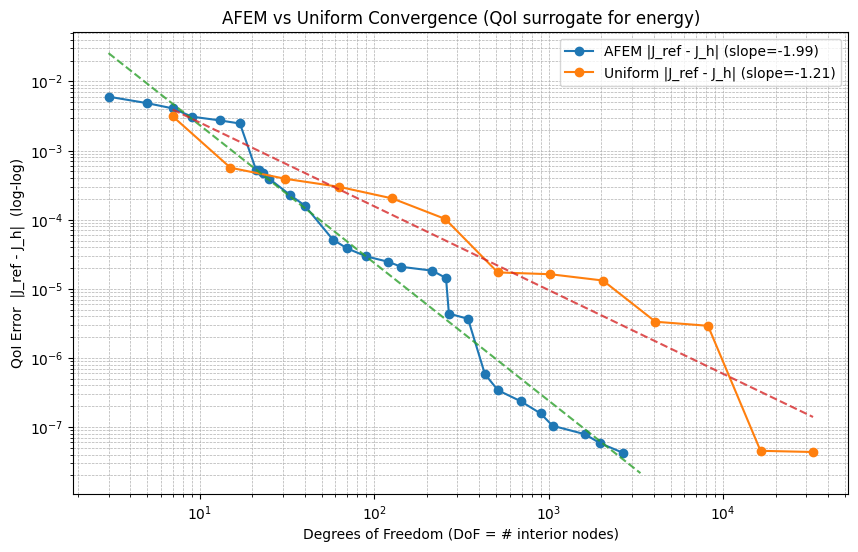

J_ref = 0.04179103220546152
AFEM ddof: [3.000e+00 5.000e+00 7.000e+00 9.000e+00 1.300e+01 1.700e+01 2.100e+01
 2.200e+01 2.300e+01 2.500e+01 3.300e+01 4.000e+01 5.800e+01 7.000e+01
 9.000e+01 1.200e+02 1.430e+02 2.150e+02 2.580e+02 2.680e+02 3.450e+02
 4.310e+02 5.120e+02 6.920e+02 8.990e+02 1.053e+03 1.615e+03 1.958e+03
 2.666e+03 3.359e+03]
AFEM err : [6.02081196e-03 4.84893696e-03 4.07861569e-03 3.09900143e-03
 2.73240903e-03 2.46380665e-03 5.30578280e-04 5.24432249e-04
 4.76669742e-04 3.92058280e-04 2.27314158e-04 1.60175475e-04
 5.14361717e-05 3.84657352e-05 2.94534547e-05 2.46850758e-05
 2.08226939e-05 1.83252894e-05 1.43428522e-05 4.39101452e-06
 3.68265552e-06 5.84841430e-07 3.41207434e-07 2.36619898e-07
 1.57550614e-07 1.04651489e-07 7.88593039e-08 5.90405221e-08
 4.24511283e-08 0.00000000e+00]
UNI  ddof: [7.0000e+00 1.5000e+01 3.1000e+01 6.3000e+01 1.2700e+02 2.5500e+02
 5.1100e+02 1.0230e+03 2.0470e+03 4.0950e+03 8.1910e+03 1.6383e+04
 3.2767e+04]
UNI  err : [3.12646725e-03 

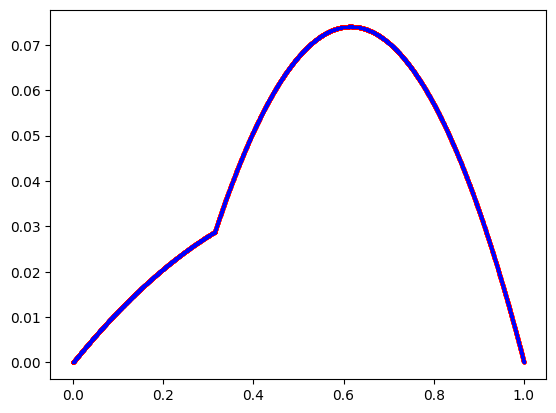

In [38]:
# ----
# RUN 
# ----
beta = (0.0, 0.3141452)     
theta = 0.6
plot_qoi_convergence(beta, theta=theta, max_iter=30, l_min=3, l_max=15)

## 5. Bayesian Inverse Problem
Why this links to Bayesian inverse problems 
- Unknown parameter $\beta$ defines the inclusion.
- Likelihood evaluation needs many forward solves $u(\beta)$.


In MCMC, we solve the forward problem $10^5$ times.
* **Uniform Mesh:** Needs ~4000 DoF for 1% accuracy.
* **AFEM:** Needs ~80 DoF for 1% accuracy.
* **Result:** 50x speedup in likelihood evaluation, making the inverse problem solvable in real-time.